# Trabajo Semanal N°0 : 'Primeros Pasos en la Simulacion'
### Alumno: Magdalena Guida

### APS - 1er cuatrimestre 2026


La primer parte del trabajo consiste en diseñar una funcion que permite generar señales senoidales con las siguientes variables:

- Amplitud maxima de la senoidal $(Vmax) [Volts]$
- Valor medio $(dc) [Volts]$
- Frecuencia $(frec = ff) [Hz]$
- Fase $(ph) [rad]$
- Cantidad de muestras a digitalizar $(N)$
- Frecuencia de muestreo $(fs) [Hz]$


In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

N = 1000     # Número de muestras
fs = N       # Frecuencia de muestreo
T = 1 / fs   # Tiempo de muestreo
df = fs / N  # Resolución espectral  
dc = 0       #Desplazamiento vertical [V]  
ph = 0       #FASE = Desplazamiento horizontal [rad]

# Definicion funciónes seno
def func_sen(Vmax=1, dc=dc, ff=1, ph=ph, nn=N, fs=fs):
    
    tt = np.arange(0, nn / fs, 1/fs ).reshape(nn,1) ## arange ( START, STOP, STEP)
    
    xx = Vmax * np.sin(2 * np.pi * ff * tt + ph).reshape(nn,1) + dc
    
    return tt, xx

El Grafico 1, presenta la señal evaluada para las frecuencias: {$1, 500, 999, 1001, 2001$} $Hz$. 

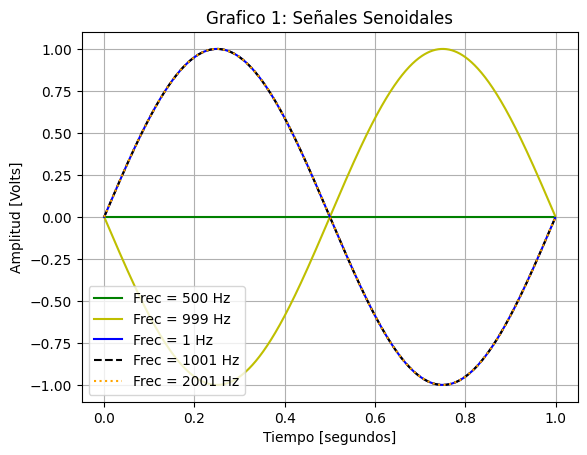

In [2]:
tt1, xx1 = func_sen(ff=1, fs=fs)
tt2, xx2 = func_sen(ff=500, fs=fs)
tt3, xx3 = func_sen(ff=999, fs=fs)
tt4, xx4 = func_sen(ff=1001, fs=fs)
tt5, xx5 = func_sen(ff=2001, fs=fs)

# GRAFICO 
# Caracteristicas del Grafico

plt.figure()
plt.title("Grafico 1: Señales Senoidales")
plt.plot(tt2, xx2, label="Frec = 500 Hz", color = 'g')
plt.plot(tt3, xx3, label="Frec = 999 Hz", color = 'y')
plt.plot(tt1, xx1, label="Frec = 1 Hz", color = 'b')
plt.plot(tt4, xx4, label="Frec = 1001 Hz", color = 'black', linestyle = '--')
plt.plot(tt5, xx5, label="Frec = 2001 Hz", color = 'orange', linestyle = 'dotted')

plt.legend(loc = 'lower left')
plt.xlabel("Tiempo [segundos]")
plt.ylabel("Amplitud [Volts]")
plt.grid(True)
plt.show()


El Grafico 1, muestra caracteristicas inesperadas para los valores de frecuencias utilizados. En primer lugar, se observa que la senoidal de frecuencia $f = 500 Hz $, es una funcion constante de valor cero. En segundo lugar, podemos ver como todas las senoidales parecen completar su ciclo en 1 segundo. Dado que la frecuencia es la inversa a la duracion de un ciclo, $T= 1 / f$, se esperaban ciclos distintos. En tercer lugar, las senoidales de frecuencias $f = $ {$1, 1001, 2001$} $Hz$ presentan exactamente la misma funcion, mientras que $f = 999 Hz$ corresponde a su inversa. 
La razon de este comportamiento se explica mediante el Teorema de Muestreo de Nyquist - Shannon, el cual establece la condicion fundamental para realizar un muestreo correcto: la frecuencia de la señal debe ser mayor o igual a la mitad de la frecuencia de muestreo $ff≤\frac{f_s}{2}$. Igualmente, para asegurar la calidad del muestreo a nivel practico, se pide $ff<<<\frac{f_s}{2}$. Si la condicion no se cumple, se produce el fenomeno de Aliasing, que significa que las frecuencias altas se 'disfrazan' de señales de frecuencias mas bajas, provocando una perdida significativa de informacion. Para determinar, de que manera se distorcionan las señales, existe una frecuencia de Alias, que se define como:  $f_{alias} =  ff - k*fs $, donde $k$ representa al numero entero, distinto de cero, mas cercano a la division entre $\frac{ff}{f_s}$. 
Aplicando esta ecuacion al caso analizado: 

- $ K = \frac{1000Hz}{1001Hz} = 0.999$  $-> K = 1 $, tal que $f_{alias} =  1001Hz - 1*1000Hz  = 1Hz$.
- $ K = \frac{1000Hz}{2001Hz} = 0.499$  $-> K = 1 $, tal que $f_{alias} = 2001Hz - 1*1000Hz   = 1001Hz$ , el proceso se repite y resulta en $f_{alias} = 1Hz$.

Asi se explica porque las senoidales de frecuencia $f=$ {$1001, 2001$} $Hz$ son indistingibles de la senoidal $f = 1Hz$. 

Si se aplica el mismo razonamiento a la señal con frecuencia de $999Hz$:

- $ K = \frac{1000Hz}{999Hz} = 1.001$  $-> K = 1 $, tal que $f_{alias} =  999Hz - 1*1000Hz  = -1Hz$, y observamos en el grafico, una señal de frecuencia de $1Hz$, pero invertida por el signo menos de $f_{alias} = -1Hz$.


Por ultimo, la senoidal de frecuencia: $500Hz$, al aplicarle el teorema, $500Hz ≤\frac{1000Hz}{2}$ $-> 500Hz = 500Hz$, se comprueba que cumple con el teorema. Sin embargo, como se especifico anteriormente, a nivel practico esto no es suficiente para recrear la señal con exactitud. Una frecuencia de muestreo exactamente 2 veces mayor a la frecuencia de la señal, lograra obtener solo dos puntos sobre el comienzo y final del ciclo, por eso se la 've' como una recta. 


La segunda parte del trabajo, consistio en experimentar con distintas formas de señales e implementarlas. Se diseño un codigo para poder graficar señales con forma'square' y 'sawtooth', manteniendo los mismos parametros definidos para la señal senoidal. En el caso de la señal cuadrada, se agrego el parametro $duty$, que representa el porcentaje  entre $[0 ; 1]$ de ancho correspondiente al pulso positivo. En este caso se define $duty = 0.5$ para obtener una funcion simetrica. La señal triangular se genero desde la funcion 'sawtooth', utilizando el parametro $width$, definido en el intervalo $[0;1]$ se determina a que distancia del punto mas bajo estara el proximo punto alto. se lo fijo con el valor $width = 0.5$ para obtener la forma caracteristica de señal triangular. Ambas señales fueron definidas para frecuencias: $3Hz$ y $1003Hz$.

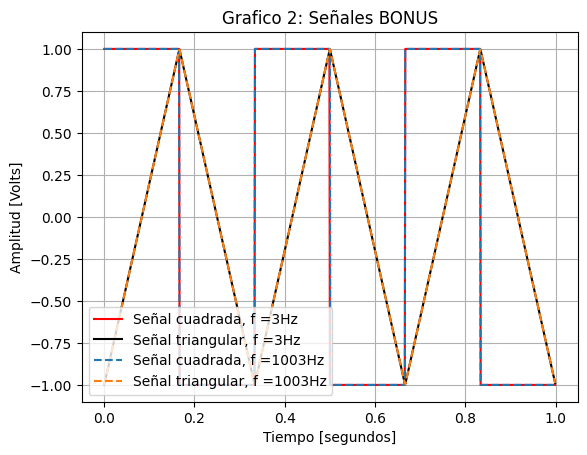

In [3]:
#%% BONUS 

def func_square(Vmax=1, dc=dc, ph=ph, nn=N, fs=fs, ff=1, duty= 1/2):
    
    tt = np.arange(0, nn/fs, 1/fs).reshape(nn, 1)
    
    xx = Vmax * signal.square(2 * np.pi * tt * ff + ph, duty=duty ).reshape(nn, 1) + dc
    
    return tt, xx

def func_triang(Vmax=1, dc=dc, ph=ph, nn=N, ff=1, fs=fs, width=1/2):
    
    tt = np.arange(0, nn/fs, 1/fs).reshape(nn, 1)
    
    xx = Vmax * signal.sawtooth(2 * np.pi * ff * tt + ph, width =width).reshape(nn, 1) + dc
   
    return tt, xx

##GRAFICO 2
tta, xxa = func_square (ff=3)    # 3 periodos enteros de la cuadrada
tta1, xxa1 = func_square(ff=1003)
ttb, xxb = func_triang(ff=3)
ttb1, xxb1 = func_triang(ff = 3)
plt.figure()
plt.title("Grafico 2: Señales BONUS")
plt.plot(tta, xxa, label="Señal cuadrada, f =3Hz", color= 'red')
plt.plot(ttb, xxb, label="Señal triangular, f =3Hz ", color= 'black')
plt.plot(tta1, xxa1, label="Señal cuadrada, f =1003Hz", linestyle= '--')
plt.plot(ttb1, xxb1, label="Señal triangular, f =1003Hz", linestyle= '--')
plt.legend(loc = 'lower left')
plt.xlabel("Tiempo [segundos]")
plt.ylabel("Amplitud [Volts]")
plt.grid(True)
plt.show()

El Grafico 2, presenta las funciones cuadradas y triangulares con distintos valores de frecuencias donde podemos observar que sucede lo mismo que se describio para las señales senosoidales: las frecuencias que no cumplen con el teorema son representadas con una frecuencia de Aliasing. Si se replica el calculo detallado anteriormente para la frecuencia de Alias, se obtiene $f_{alias}= 3Hz$. 

El analisis realizado permitio experimentar con señales senidales, cuadradas y triangulares, verificando como sus parametros caracteristicos influyen en la representacion grafica. Este proceso puso en evidencia que el diseño de una funcion no solo depende de la funcion matematica utilizada, sino tambien de la correcta eleccion de parametros de muestreo. Se concluye entonces, que la relacion entre frecuencia de muestreo $fs$ y  frecuencia de señal $ff$, puede ser clasificada en los siguientes rangos: 

- *Cumple Nyquist* = $ff$ MENOR a $\frac{f_s}{2}$ --> La señal se muestreara correctamente.
- $ff = \frac{f_s}{2}$ --> Constante con el valor de DC. Tambien sucedera lo MISMO para valores de $ff = \frac{f_s}{2} + m*ff$, siendo m un numero entero.
- *NO cumple Nyquist* = $ff$ MAYOR a $\frac{f_s}{2}$--> Se muestrearan con su frecuencia $f_{alias}$.
- $ ff = f_s$ --> **NO** se muestreara. Tambien sucedera para valores de $ff = ff + m*ff$, siendo m un numero entero.

Para asi poder anticipar el comportamiento de la señal conociendo la frecuencia de señal y frecuencia de muestreo  y garantizar que las señales representen fielmente la informacion a transmitir.